# Artem Ivaniuk, Stat 565 Project
### Paper Replication Notebook

Replication Notebook for Gidea & Katz (2017)

Topological Data Analysis of Financial Time Series: Landscapes of Crashes**  
Marian Gidea and Yuri Katz, arXiv:1703.04385

#### Environment Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

from dataclasses import dataclass
from typing import Dict, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ripser import ripser
from scipy.stats import kendalltau

import yfinance as yf

sns.set_theme(style="whitegrid")
plt.rcParams.update(
    {
        "font.size": 14,
        "axes.titlesize": 15,
        "axes.labelsize": 14,
        "xtick.labelsize": 13,
        "ytick.labelsize": 13,
        "legend.fontsize": 13,
        "figure.titlesize": 15,
    }
)

In [2]:
TICKERS = {
    "SP500": "^GSPC",
    "DJIA": "^DJI",
    "NASDAQ": "^IXIC",
    "RUSSELL2000": "^RUT",
    "VIX": "^VIX",
}

START_DATE = "1987-12-23"
END_DATE = "2016-12-09"  # end is exclusive in yfinance

WINDOWS = [50, 100]
ROLLING_STATS_WINDOW = 500
PRE_CRASH_DAYS = 250

CRASH_DATES = {
    "DotCom": pd.Timestamp("2000-03-10"),
    "Lehman": pd.Timestamp("2008-09-15"),
}

#### Data Preprocessing

In [3]:
def download_adjusted_close(tickers: Dict[str, str], start: str, end: str) -> pd.DataFrame:
    raw = yf.download(
        list(tickers.values()),
        start=start,
        end=end,
        auto_adjust=False,
        progress=False,
        group_by="column",
    )

    # yfinance returns MultiIndex columns for multiple symbols
    if isinstance(raw.columns, pd.MultiIndex):
        adj = raw["Adj Close"].copy()
    else:
        adj = raw[["Adj Close"]].rename(columns={"Adj Close": list(tickers.values())[0]})

    inv = {v: k for k, v in tickers.items()}
    adj = adj.rename(columns=inv).sort_index()
    return adj


def compute_log_returns(prices: pd.DataFrame) -> pd.DataFrame:
    # Forward daily log-return: ln(P_t / P_{t-1})
    return np.log(prices / prices.shift(1)).dropna()


prices = download_adjusted_close(TICKERS, START_DATE, END_DATE)
returns = compute_log_returns(prices[["SP500", "DJIA", "NASDAQ", "RUSSELL2000"]])
vix = prices[["VIX"]].reindex(returns.index).dropna()

print("Prices shape:", prices.shape)
print("Returns shape:", returns.shape)
print("Returns period:", returns.index.min().date(), "->", returns.index.max().date())

Prices shape: (7301, 5)
Returns shape: (6283, 4)
Returns period: 1992-01-03 -> 2016-12-08


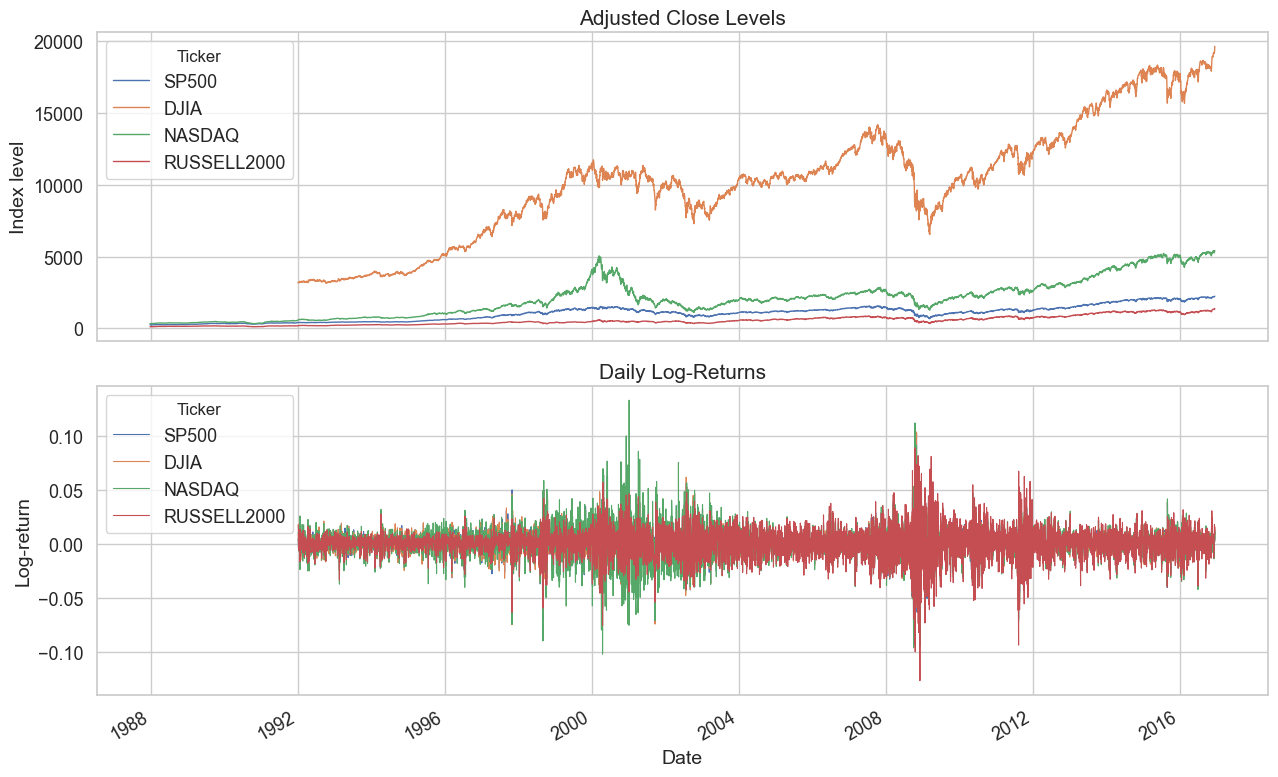

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
prices[["SP500", "DJIA", "NASDAQ", "RUSSELL2000"]].plot(ax=axes[0], linewidth=1)
axes[0].set_title("Adjusted Close Levels")
axes[0].set_ylabel("Index level")

returns.plot(ax=axes[1], linewidth=0.8)
axes[1].set_title("Daily Log-Returns")
axes[1].set_ylabel("Log-return")
plt.tight_layout()

#### TDA Utility Functions

In [5]:
def _tent_values(t: np.ndarray, b: float, d: float) -> np.ndarray:
    return np.maximum(0.0, np.minimum(t - b, d - t))


def landscape_lp_norm_from_diagram(diagram: np.ndarray, p: int = 1, grid_size: int = 256) -> float:
    if diagram.size == 0:
        return 0.0

    finite_mask = np.isfinite(diagram).all(axis=1)
    dgm = diagram[finite_mask]
    if dgm.size == 0:
        return 0.0

    births = dgm[:, 0]
    deaths = dgm[:, 1]

    tmin = float(np.min(births))
    tmax = float(np.max(deaths))
    if tmax <= tmin:
        return 0.0

    t = np.linspace(tmin, tmax, grid_size)
    vals = np.vstack([_tent_values(t, b, d) for b, d in dgm])

    vals_sorted = np.sort(vals, axis=0)[::-1]
    if p == 1:
        total = np.trapezoid(np.sum(vals_sorted, axis=0), t)
        return float(total)

    if p == 2:
        total = np.trapezoid(np.sum(vals_sorted ** 2, axis=0), t)
        return float(np.sqrt(total))

    total = np.trapezoid(np.sum(vals_sorted ** p, axis=0), t)
    return float(total ** (1.0 / p))


def h1_diagram_from_point_cloud(X: np.ndarray) -> np.ndarray:
    out = ripser(X, maxdim=1)
    return out["dgms"][1]


def rolling_landscape_norms(data: pd.DataFrame, window: int, grid_size: int = 256) -> pd.DataFrame:
    rows = []
    idx = []
    arr = data.values

    for i in range(len(data) - window + 1):
        X = arr[i : i + window, :]
        dgm1 = h1_diagram_from_point_cloud(X)
        l1 = landscape_lp_norm_from_diagram(dgm1, p=1, grid_size=grid_size)
        l2 = landscape_lp_norm_from_diagram(dgm1, p=2, grid_size=grid_size)
        rows.append((l1, l2))
        idx.append(data.index[i + window - 1])

    return pd.DataFrame(rows, index=pd.DatetimeIndex(idx), columns=["L1", "L2"])

#### Rolling TDA Computation

In [6]:
norms_by_window = {}
for w in WINDOWS:
    print(f"Computing norms for window={w}...")
    norms_by_window[w] = rolling_landscape_norms(returns, window=w, grid_size=256)

norms_by_window[50].head()

Computing norms for window=50...
Computing norms for window=100...


,L1,L2
1992-03-13,0.000002,0.000023
1992-03-16,0.000001,0.000020
1992-03-17,0.000002,0.000027
1992-03-18,0.000002,0.000025
1992-03-19,0.000001,0.000024


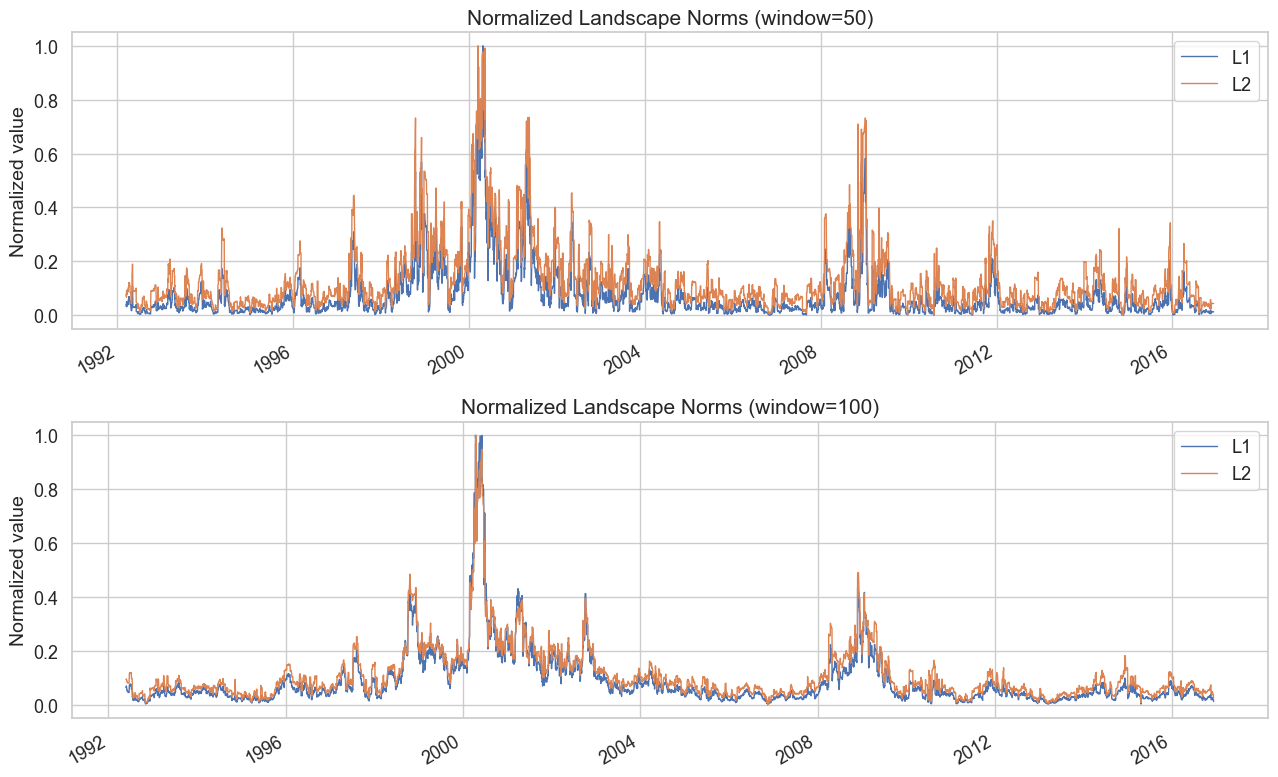

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=False)
for ax, w in zip(axes, WINDOWS):
    df = norms_by_window[w]
    scaled = (df - df.min()) / (df.max() - df.min())
    scaled[["L1", "L2"]].plot(ax=ax, linewidth=1)
    ax.set_title(f"Normalized Landscape Norms (window={w})")
    ax.set_ylabel("Normalized value")
plt.tight_layout()

#### Event-Centered Comparison Plots

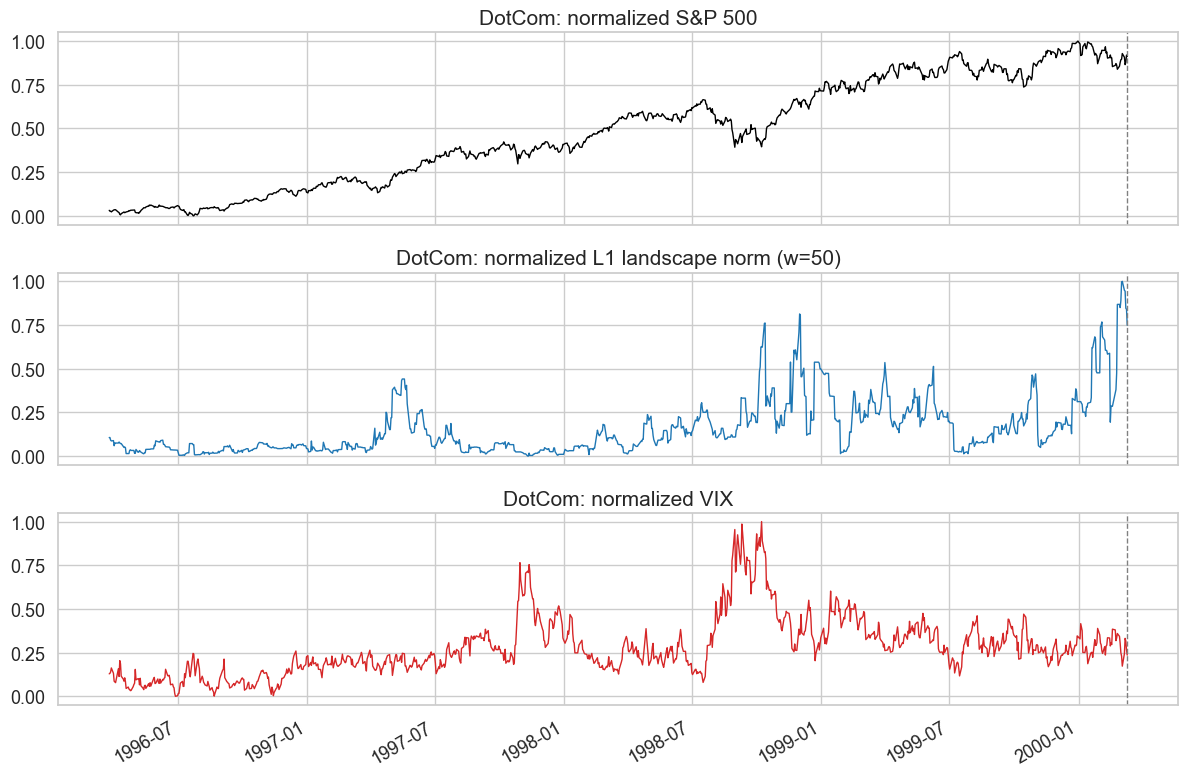

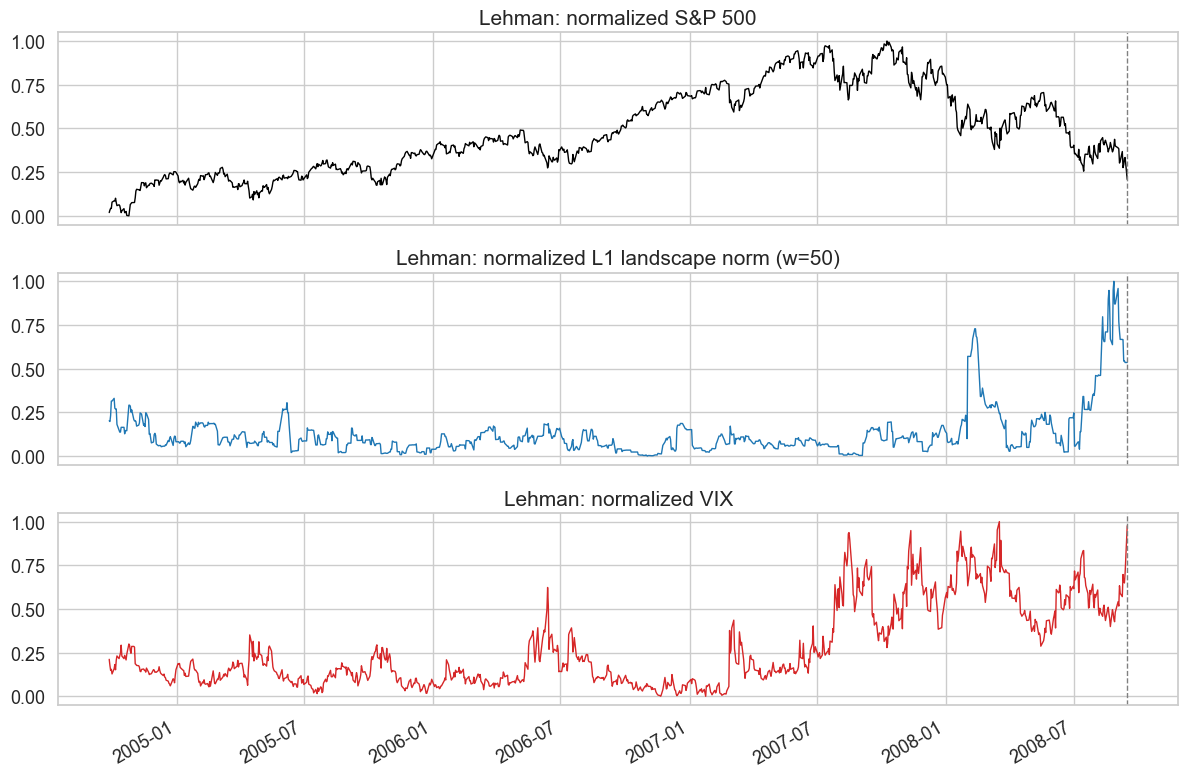

In [8]:
def normalize(s: pd.Series) -> pd.Series:
    return (s - s.min()) / (s.max() - s.min())


def pre_crash_slice(series: pd.Series, crash_date: pd.Timestamp, n_days: int = 1000) -> pd.Series:
    series = series.sort_index()
    subset = series.loc[:crash_date]
    return subset.iloc[-n_days:]


norm50 = norms_by_window[50]["L1"].copy()
spx = prices["SP500"].reindex(norm50.index).ffill()
vix_s = vix["VIX"].reindex(norm50.index).ffill()

for label, date in CRASH_DATES.items():
    s_spx = normalize(pre_crash_slice(spx, date, 1000))
    s_l1 = normalize(pre_crash_slice(norm50, date, 1000))
    s_vix = normalize(pre_crash_slice(vix_s, date, 1000))

    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
    s_spx.plot(ax=axes[0], color="black", linewidth=1)
    axes[0].set_title(f"{label}: normalized S&P 500")

    s_l1.plot(ax=axes[1], color="tab:blue", linewidth=1)
    axes[1].set_title(f"{label}: normalized L1 landscape norm (w=50)")

    s_vix.plot(ax=axes[2], color="tab:red", linewidth=1)
    axes[2].set_title(f"{label}: normalized VIX")

    for ax in axes:
        ax.axvline(date, color="gray", linestyle="--", linewidth=1)
    plt.tight_layout()


#### Early-Warning Statistics and Trend Tests

In [9]:
def rolling_low_freq_power(series: pd.Series, window: int = 500, low_bins: int = 5) -> pd.Series:
    vals = series.values.astype(float)
    out = np.full_like(vals, np.nan, dtype=float)
    for i in range(window - 1, len(vals)):
        x = vals[i - window + 1 : i + 1]
        x = x - np.nanmean(x)
        f = np.fft.rfft(np.nan_to_num(x))
        psd = np.abs(f) ** 2
        out[i] = np.nanmean(psd[1 : 1 + low_bins])
    return pd.Series(out, index=series.index)


def rolling_variance(series: pd.Series, window: int = 500) -> pd.Series:
    return series.rolling(window).var()


def trend_test_pre_crash(series: pd.Series, crash_date: pd.Timestamp, n: int = 250) -> Tuple[float, float]:
    s = series.dropna().loc[:crash_date].iloc[-n:]
    if len(s) < 10:
        return np.nan, np.nan
    x = np.arange(len(s))
    tau, p = kendalltau(x, s.values)
    return float(tau), float(p)


l1_50 = norms_by_window[50]["L1"]
var_l1 = rolling_variance(l1_50, window=ROLLING_STATS_WINDOW)
spec_l1 = rolling_low_freq_power(l1_50, window=ROLLING_STATS_WINDOW, low_bins=5)

for label, date in CRASH_DATES.items():
    tau_var, p_var = trend_test_pre_crash(var_l1, date, n=PRE_CRASH_DAYS)
    tau_spec, p_spec = trend_test_pre_crash(spec_l1, date, n=PRE_CRASH_DAYS)
    print(f"{label} | Variance trend: tau={tau_var:.3f}, p={p_var:.3g}")
    print(f"{label} | Low-freq PSD trend: tau={tau_spec:.3f}, p={p_spec:.3g}")


DotCom | Variance trend: tau=-0.223, p=1.44e-07
DotCom | Low-freq PSD trend: tau=-0.602, p=1.42e-45
Lehman | Variance trend: tau=0.888, p=4.36e-97
Lehman | Low-freq PSD trend: tau=0.691, p=1.4e-59


#### Save Replication Outputs

In [10]:
out_dir = "results"
import os
os.makedirs(out_dir, exist_ok=True)

returns.to_csv(f"{out_dir}/returns_4indices.csv")
vix.to_csv(f"{out_dir}/vix.csv")

for w, df in norms_by_window.items():
    df.to_csv(f"{out_dir}/landscape_norms_w{w}.csv")

print("Saved outputs to:", out_dir)

Saved outputs to: results
